In [7]:
# Import Data Manipulation Libraries
import numpy as np
import pandas as pd
# Import Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns 
# Import Required Machine Learning Libraries 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,MinMaxScaler,RobustScaler
from sklearn.impute import SimpleImputer,KNNImputer
# Import Logging 
import logging
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S',
                    filename='app.log',
                    filemode='w',
                    force=True)

# Import Warnings
import warnings
warnings.filterwarnings('ignore')
# Import Operating System
import sys
import os
# Model Deployment File
import pickle

In [8]:
# Define Data 
df = pd.read_csv(r'/Users/kuldeepgaud/supply_chain_predictionmodel/data/SCM.csv')
df.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071


In [ ]:
# Display the information about dataset
df.info()
''' 
Note:- from df.info() we got to know that datset has 24 features and 2 of the features has some missing entries.
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22150 entries, 0 to 22149
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 22150 non-null  object 
 1   WH_Manager_ID                 22150 non-null  object 
 2   Location_type                 22150 non-null  object 
 3   WH_capacity_size              22150 non-null  object 
 4   zone                          22150 non-null  object 
 5   WH_regional_zone              22150 non-null  object 
 6   num_refill_req_l3m            22150 non-null  int64  
 7   transport_issue_l1y           22150 non-null  int64  
 8   Competitor_in_mkt             22150 non-null  int64  
 9   retail_shop_num               22150 non-null  int64  
 10  wh_owner_type                 22150 non-null  object 
 11  distributor_num               22150 non-null  int64  
 12  flood_impacted                22150 non-null  int64  
 13  f

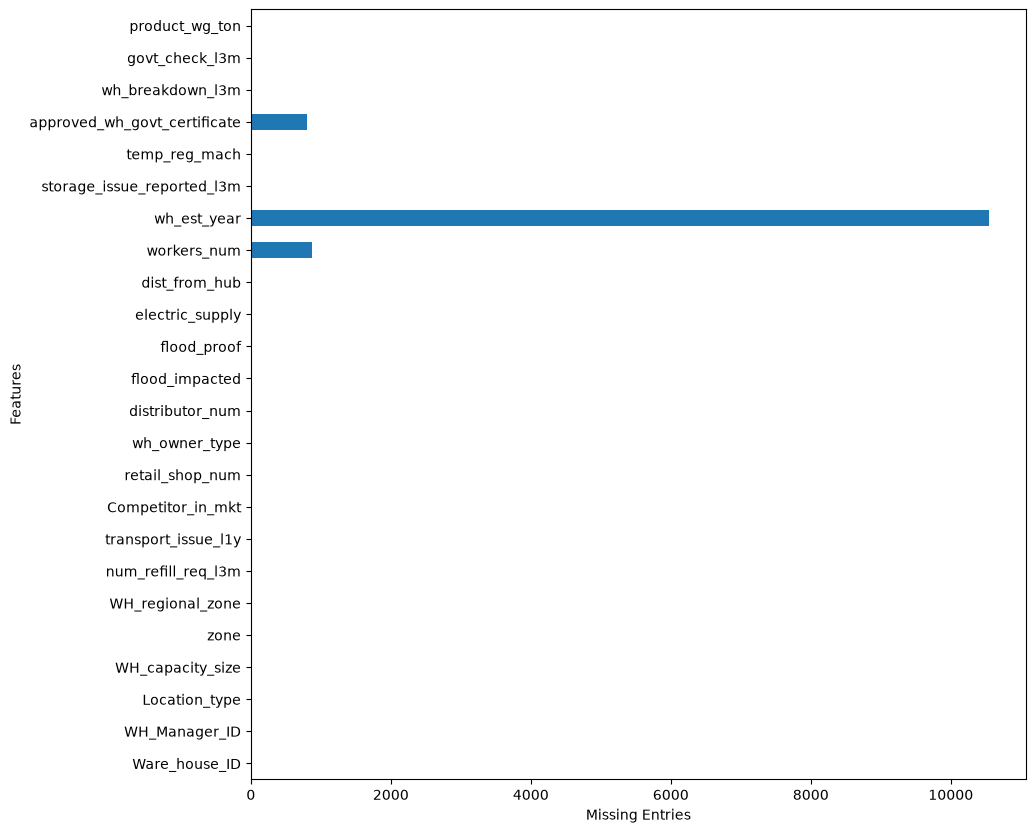

In [ ]:
# Check the total number of missing value 
plt.figure(figsize = [10,10])
df.isnull().sum().plot(kind = 'barh')
plt.ylabel('Features')
plt.xlabel('Missing Entries')
plt.show()

''' 
wh_est_year has the highest number of missing entries
'''

In [ ]:
# Check the duplicated the values in the dataset 
df.duplicated().sum()
''' 
no null values present in the dataset
'''

np.int64(0)

In [26]:
# Describe the numerical and categorical columns
categorical_data = df.select_dtypes(include = 'object').columns
numerical_data = df.select_dtypes(exclude = ['int64', 'float64']).columns

In [17]:
# Display the descriptive statistics of categorical data
df.describe(include = 'object')

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,wh_owner_type,approved_wh_govt_certificate
count,22150,22150,22150,22150,22150,22150,22150,21345
unique,22150,22150,2,3,4,6,2,5
top,WH_100000,EID_50000,Rural,Large,North,Zone 6,Company Owned,C
freq,1,1,20334,8968,9069,7376,12035,4859


In [ ]:
# Display the descriptive statistics of numerical columns
from collections import OrderedDict

stats = []

for i in numerical_data:
    num_stats = OrderedDict({
        'feature ': i,
        'mean': df[i].mean(),
        'median':df[i].median(),
        'Q1' : df[i].quantile(0.25),
        'Q3' : df[i].quantile(0.75),
        'IQR' : df[i].quantile(0.75) - df[i].quantile(0.25),
        'lower whisker': df[i].quantile(0.25) - 1.5*df[i].quantile(0.75) - df[i].quantile(0.25),
        'upper whiaker': df[i].quantile(0.75) + 1.5*df[i].quantile(0.75) - df[i].quantile(0.25),
        'standard deviation' : df[i].std(),
        'skewness' : df[i].skew(),
        'kurtosis' : df[i].kurt(),
        'outlier %': (
            ((df[i] < (df[i].quantile(0.25) -1.5 * (df[i].quantile(0.75) - df[i].quantile(0.25)))) |
                (df[i] > (df[i].quantile(0.75) +1.5 * (df[i].quantile(0.75) - df[i].quantile(0.25))))).sum() / df[i].notna().sum() ) * 100
    })
    stats.append(num_stats)
    report = pd.DataFrame(stats)
report

,feature,mean,median,Q1,Q3,IQR,lower whisker,upper whiaker,standard deviation,skewness,kurtosis,outlier %
0,num_refill_req_l3m,4.097020,4.0,2.00,6.0,4.00,-9.0,13.00,2.606289,-0.081390,-1.218193,0.000000
1,transport_issue_l1y,0.777201,0.0,0.00,1.0,1.00,-1.5,2.50,1.201747,1.605424,1.820683,11.864560
2,Competitor_in_mkt,3.103928,3.0,2.00,4.0,2.00,-6.0,8.00,1.142886,0.985102,1.798511,0.383747
3,retail_shop_num,4983.115711,4859.0,4309.25,5499.0,1189.75,-8248.5,9438.25,1050.634225,0.905324,1.846915,3.724605
4,distributor_num,42.386998,42.0,29.00,56.0,27.00,-84.0,111.00,16.057730,0.017210,-1.187118,0.000000
5,flood_impacted,0.098691,0.0,0.00,0.0,0.00,0.0,0.00,0.298253,2.691308,5.243614,9.869074
6,flood_proof,0.054492,0.0,0.00,0.0,0.00,0.0,0.00,0.226991,3.925685,13.412215,5.449210
7,electric_supply,0.656072,1.0,0.00,1.0,1.00,-1.5,2.50,0.475028,-0.657167,-1.568273,0.000000
8,dist_from_hub,163.613725,164.0,109.00,218.0,109.00,-327.0,436.00,62.660709,-0.009042,-1.200679,0.000000
9,workers_num,28.936398,28.0,24.00,33.0,9.00,-49.5,58.50,7.843431,1.042478,3.285720,2.505523


In [27]:
# Display the correlation of features with target column
df.corr()['product_wg_ton'].sort_values(ascending=False).plot(kind='barh')
plt.axvline(x=0,linestyle='--',color='k')
plt.show()

ValueError: could not convert string to float: 'WH_100000'